# EDA Who pays

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
# Daten laden
okp = pd.read_csv('../data/whopays/processed_whopays/okp_by_birth_year.csv')
ahv_ein = pd.read_csv('../data/whopays/processed_whopays/ahv_einnahmen_by_birth_year.csv')
ahv_aus = pd.read_csv('../data/whopays/processed_whopays/ahv_ausgaben_by_age.csv')

# Erste Übersicht
for name, df in [('OKP', okp), ('AHV Einnahmen', ahv_ein), ('AHV Ausgaben', ahv_aus)]:
    print(f'=== {name} ===')
    print(f'Shape: {df.shape}')
    print(f'Spalten: {list(df.columns)}')
    print()

=== OKP ===
Shape: (18403, 15)
Spalten: ['year', 'variable_name', 'age_group_label', 'age_min', 'age_max', 'metric', 'value', 'unit', 'scale', 'notes', 'age', 'birth_year', 'project_age_group', 'project_age_order', 'method']

=== AHV Einnahmen ===
Shape: (4545, 15)
Spalten: ['year', 'variable_name', 'age_group_label', 'age_min', 'age_max', 'metric', 'value', 'unit', 'scale', 'notes', 'age', 'birth_year', 'project_age_group', 'project_age_order', 'method']

=== AHV Ausgaben ===
Shape: (1404, 11)
Spalten: ['year', 'variable_name', 'age', 'birth_year', 'project_age_group', 'project_age_order', 'metric', 'value', 'unit', 'scale', 'notes']



In [24]:
# Was sind die eindeutigen Werte in den wichtigsten Kategoriespalten?
print('=== OKP Metriken ===')
print(okp['metric'].unique())
print(okp['variable_name'].unique())

print('\n=== AHV Einnahmen Metriken ===')
print(ahv_ein['metric'].unique())

print('\n=== AHV Ausgaben Metriken ===')
print(ahv_aus['metric'].unique())

print('\n=== Generationen (OKP) ===')
print(okp[['project_age_group', 'project_age_order']].drop_duplicates().sort_values('project_age_order').to_string(index=False))

=== OKP Metriken ===
['beneficiaries_count' 'beneficiary_rate' 'total_mio_chf' 'per_capita_chf']
['praemienverbilligung' 'okp_kostenbeteiligung' 'okp_nettoleistungen'
 'okp_bruttoleistungen' 'okp_premium']

=== AHV Einnahmen Metriken ===
['n_personen' 'sum_einkommen' 'sum_beitrag_ahv']

=== AHV Ausgaben Metriken ===
['anzahl_renten' 'rentensumme_tausend_chf' 'renten_mittelwert_chf']

=== Generationen (OKP) ===
project_age_group  project_age_order
Silent Generation                  1
      Babyboomers                  2
     Generation X                  3
      Millennials                  4
     Generation Z                  5
 Generation Alpha                  6


In [25]:
# Geburtsjahre in der OKP-Datei prüfen
print('Geburtsjahr-Bereich pro Generation:')
print(okp.groupby('project_age_group')['birth_year'].agg(['min', 'max', 'count']))
print()
print('Sind Geburtsjahre 1997-2012 vorhanden?')
print(okp[(okp['birth_year'] >= 1997) & (okp['birth_year'] <= 2012)]['birth_year'].unique())

Geburtsjahr-Bereich pro Generation:
                    min   max  count
project_age_group                   
Babyboomers        1946  1964   3534
Generation Alpha   2013  2024    858
Generation X       1965  1980   2976
Generation Z       1997  2012   2840
Millennials        1981  1996   2980
Silent Generation  1906  1945   5215

Sind Geburtsjahre 1997-2012 vorhanden?
[2006 2005 2004 2003 2002 2001 2000 1999 1998 1997 2007 2008 2009 2010
 2011 2012]


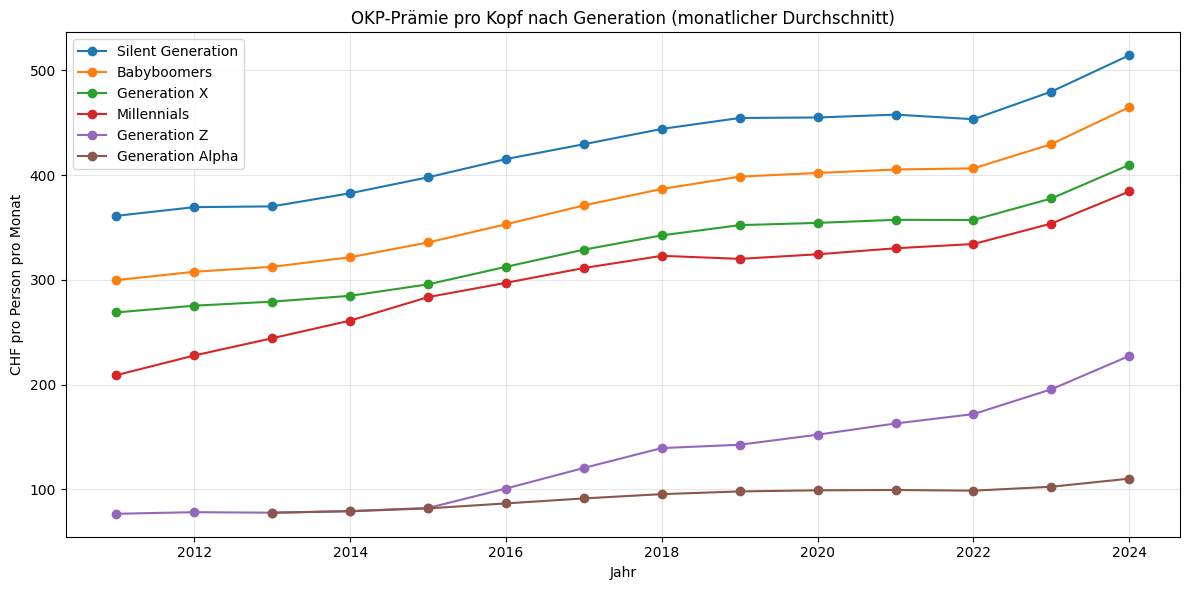

In [26]:
# Belastung durch Krankenkassenprämien
df_plot = okp[
    (okp['variable_name'] == 'okp_premium') &
    (okp['metric'] == 'per_capita_chf')
].copy()

# Jahreswert in Monatswert umrechnen
df_plot['value_monthly'] = df_plot['value'] / 12

gen_year = (
    df_plot
    .groupby(['project_age_group', 'project_age_order', 'year'])['value_monthly']
    .mean()
    .reset_index()
    .sort_values(['project_age_order', 'year'])
)

fig, ax = plt.subplots(figsize=(12, 6))

for gen in gen_year.sort_values('project_age_order')['project_age_group'].unique():
    subset = gen_year[gen_year['project_age_group'] == gen]
    ax.plot(subset['year'], subset['value_monthly'], marker='o', label=gen)

ax.set_title('OKP-Prämie pro Kopf nach Generation (monatlicher Durchschnitt)')
ax.set_xlabel('Jahr')
ax.set_ylabel('CHF pro Person pro Monat')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Methodische Einschränkung dieser Darstellung:**  
Der Wert für Generation Z und Generation Alpha ist verzerrt weil er Kinder mit Kindertarifen und junge Erwachsene mit Erwachsenentarifen vermischt.  
Der steil ansteigende Verlauf von Generation Z zeigt primär die Alterungsverschiebung der Kohorte – nicht einen realen Prämienanstieg.  
Das ist wichtig für die spätere Interpretation in der Visualisierung.

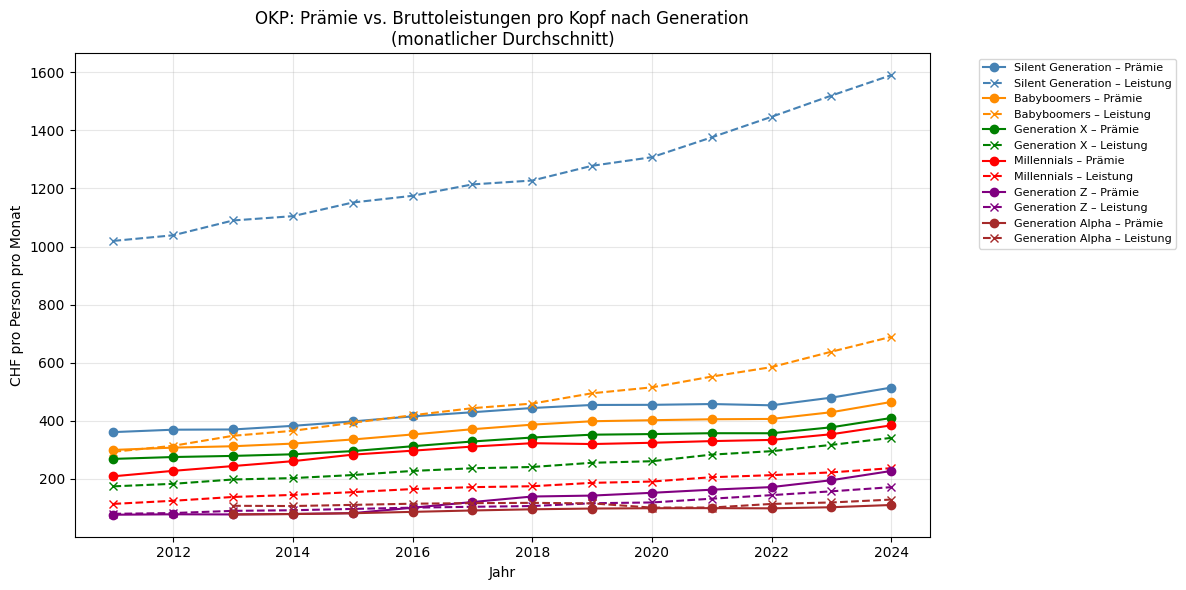

In [27]:
# OKP-Prämie UND Bruttoleistungen pro Kopf nach Generation
fig, ax = plt.subplots(figsize=(12, 6))

# Farbpalette pro Generation
farben = {
    'Silent Generation': 'steelblue',
    'Babyboomers': 'darkorange',
    'Generation X': 'green',
    'Millennials': 'red',
    'Generation Z': 'purple',
    'Generation Alpha': 'brown'
}

for gen in ['Silent Generation', 'Babyboomers', 'Generation X', 
            'Millennials', 'Generation Z', 'Generation Alpha']:
    
    # Prämien (durchgezogene Linie)
    df_praemie = okp[
        (okp['variable_name'] == 'okp_premium') &
        (okp['metric'] == 'per_capita_chf') &
        (okp['project_age_group'] == gen)
    ].groupby('year')['value'].mean() / 12
    
    # Bruttoleistungen (gestrichelte Linie)
    df_leistung = okp[
        (okp['variable_name'] == 'okp_bruttoleistungen') &
        (okp['metric'] == 'per_capita_chf') &
        (okp['project_age_group'] == gen)
    ].groupby('year')['value'].mean() / 12
    
    farbe = farben[gen]
    ax.plot(df_praemie.index, df_praemie.values, 
            color=farbe, linestyle='-', marker='o', label=f'{gen} – Prämie')
    ax.plot(df_leistung.index, df_leistung.values, 
            color=farbe, linestyle='--', marker='x', label=f'{gen} – Leistung')

ax.set_title('OKP: Prämie vs. Bruttoleistungen pro Kopf nach Generation\n(monatlicher Durchschnitt)')
ax.set_xlabel('Jahr')
ax.set_ylabel('CHF pro Person pro Monat')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Bemerkung: Bei den geleisteten Prämien sind in dieser Darstellung die Prämienverbilligung noch nicht abgezogen**

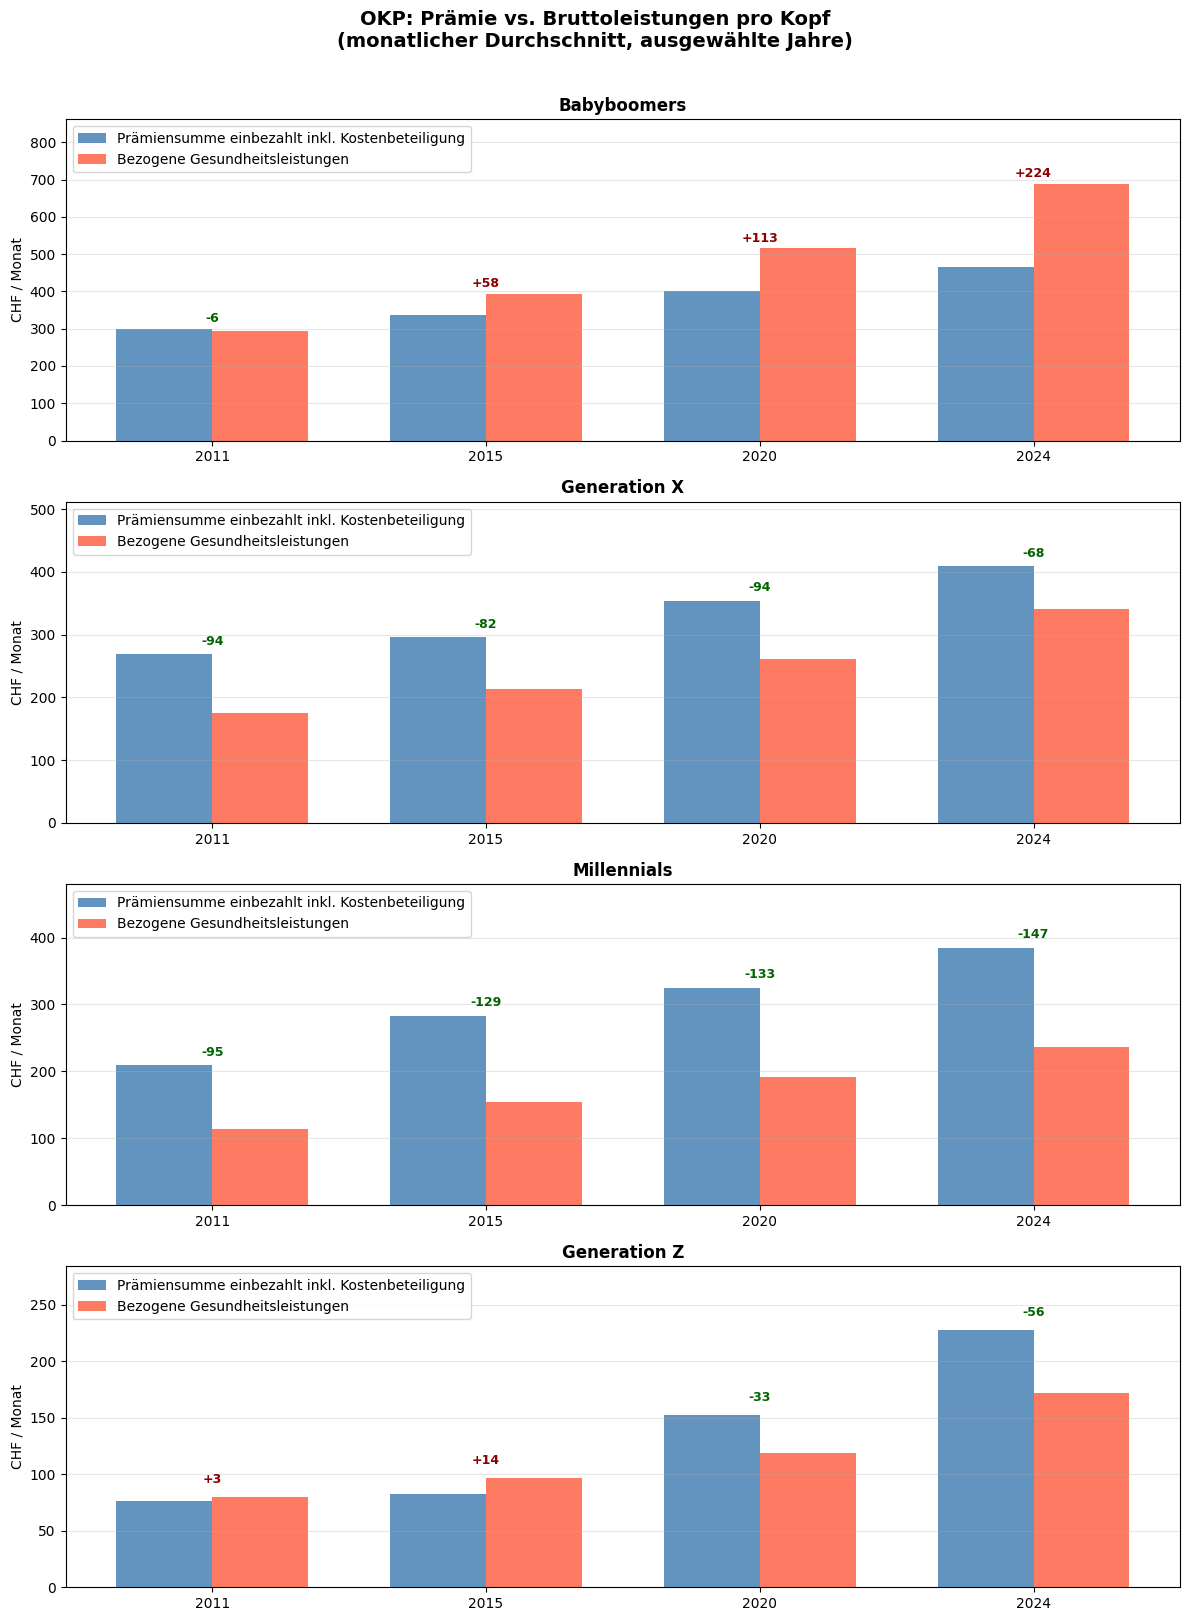

In [28]:
generationen = ['Babyboomers', 'Generation X', 'Millennials', 'Generation Z']
okp_jahre = sorted(
    set(okp[(okp['variable_name'] == 'okp_premium') & (okp['metric'] == 'per_capita_chf')]['year'].unique()) &
    set(okp[(okp['variable_name'] == 'okp_bruttoleistungen') & (okp['metric'] == 'per_capita_chf')]['year'].unique())
)
idx = [0, len(okp_jahre)//3, 2*len(okp_jahre)//3, -1]
jahre = [okp_jahre[i] for i in idx]

fig, axes = plt.subplots(4, 1, figsize=(12, 16))
fig.suptitle('OKP: Prämie vs. Bruttoleistungen pro Kopf\n(monatlicher Durchschnitt, ausgewählte Jahre)', 
             fontsize=14, fontweight='bold', y=1.01)

for idx, gen in enumerate(generationen):
    ax = axes[idx]
    
    praemien = []
    leistungen = []
    
    for jahr in jahre:
        # Prämie pro Kopf/Monat
        p = okp[
            (okp['variable_name'] == 'okp_premium') &
            (okp['metric'] == 'per_capita_chf') &
            (okp['project_age_group'] == gen) &
            (okp['year'] == jahr)
        ]['value'].mean() / 12
        
        # Bruttoleistung pro Kopf/Monat
        l = okp[
            (okp['variable_name'] == 'okp_bruttoleistungen') &
            (okp['metric'] == 'per_capita_chf') &
            (okp['project_age_group'] == gen) &
            (okp['year'] == jahr)
        ]['value'].mean() / 12
        
        praemien.append(p)
        leistungen.append(l)
    
    x = range(len(jahre))
    breite = 0.35
    
    balken_p = ax.bar([i - breite/2 for i in x], praemien, 
                       breite, label='Prämiensumme einbezahlt inkl. Kostenbeteiligung', color='steelblue', alpha=0.85)
    balken_l = ax.bar([i + breite/2 for i in x], leistungen, 
                       breite, label='Bezogene Gesundheitsleistungen', color='tomato', alpha=0.85)
    
    # Fehlbetrag als Beschriftung
    for i, (p, l) in enumerate(zip(praemien, leistungen)):
        differenz = l - p
        farbe = 'darkred' if differenz > 0 else 'darkgreen'
        symbol = '+' if differenz > 0 else ''
        ax.text(i, max(p, l) + 10, f'{symbol}{differenz:.0f}', 
                ha='center', va='bottom', fontsize=9, color=farbe, fontweight='bold')
    
    ax.set_title(gen, fontweight='bold')
    ax.set_xticks(list(x))
    ax.set_xticklabels([str(j) for j in jahre])
    ax.set_ylabel('CHF / Monat')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(max(praemien), max(leistungen)) * 1.25)

plt.tight_layout()
plt.show()

In [29]:
# Prüfung: Prämienverbilligung total_mio_chf und beneficiaries_count für 2024, Babyboomers
pv = okp[
    (okp['variable_name'] == 'praemienverbilligung') &
    (okp['metric'] == 'total_mio_chf') &
    (okp['project_age_group'] == 'Babyboomers') &
    (okp['year'] == 2024)
][['age', 'age_group_label', 'value']].head(10)
print('Prämienverbilligung total_mio_chf (Babyboomers, 2024):')
print(pv.to_string(index=False))

print()

bc = okp[
    (okp['variable_name'] == 'okp_premium') &
    (okp['metric'] == 'beneficiaries_count') &
    (okp['project_age_group'] == 'Babyboomers') &
    (okp['year'] == 2024)
][['age', 'value']].head(10)
print('Versicherte okp_premium (Babyboomers, 2024):')
print(bc.to_string(index=False))

Prämienverbilligung total_mio_chf (Babyboomers, 2024):
 age age_group_label     value
  60         56 – 60 82.059022
  61         61 – 65 90.415778
  62         61 – 65 86.197543
  63         61 – 65 82.209750
  64         61 – 65 78.911857
  65         61 – 65 75.413129
  66         66 – 70 84.870454
  67         66 – 70 82.116027
  68         66 – 70 79.137581
  69         66 – 70 75.499378

Versicherte okp_premium (Babyboomers, 2024):
Empty DataFrame
Columns: [age, value]
Index: []


In [30]:
print('Alle Metriken pro variable_name:')
print(okp.groupby(['variable_name', 'metric']).size().to_string())

Alle Metriken pro variable_name:
variable_name          metric             
okp_bruttoleistungen   per_capita_chf         1428
                       total_mio_chf          1938
okp_kostenbeteiligung  per_capita_chf         1428
                       total_mio_chf          1938
okp_nettoleistungen    per_capita_chf         1428
                       total_mio_chf          1938
okp_premium            per_capita_chf         1430
                       total_mio_chf          1937
praemienverbilligung   beneficiaries_count    1741
                       beneficiary_rate       1741
                       total_mio_chf          1456


In [31]:
# Per-Capita-Prämienverbilligung berechnen für Babyboomers 2024
pv_total = okp[
    (okp['variable_name'] == 'praemienverbilligung') &
    (okp['metric'] == 'total_mio_chf') &
    (okp['project_age_group'] == 'Babyboomers') &
    (okp['year'] == 2024)
].set_index('age')['value']

pv_count = okp[
    (okp['variable_name'] == 'praemienverbilligung') &
    (okp['metric'] == 'beneficiaries_count') &
    (okp['project_age_group'] == 'Babyboomers') &
    (okp['year'] == 2024)
].set_index('age')['value']

pv_rate = okp[
    (okp['variable_name'] == 'praemienverbilligung') &
    (okp['metric'] == 'beneficiary_rate') &
    (okp['project_age_group'] == 'Babyboomers') &
    (okp['year'] == 2024)
].set_index('age')['value']

# Gesamtversicherte = Bezüger / Rate
n_versicherte = pv_count / (pv_rate / 100)
pv_per_capita_year = (pv_total * 1_000_000) / n_versicherte
pv_per_capita_month = pv_per_capita_year / 12

print('Per-Capita Prämienverbilligung pro Monat (Babyboomers, 2024, erste 10 Jahrgänge):')
print(pv_per_capita_month.head(10).round(2).to_string())
print(f'\nDurchschnitt über alle Babyboomers-Jahrgänge: CHF {pv_per_capita_month.mean():.2f}/Monat')

Per-Capita Prämienverbilligung pro Monat (Babyboomers, 2024, erste 10 Jahrgänge):
age
60    0.52
61    0.60
62    0.60
63    0.60
64    0.60
65    0.60
66    0.71
67    0.71
68    0.71
69    0.71

Durchschnitt über alle Babyboomers-Jahrgänge: CHF 0.69/Monat


In [32]:
print('Beneficiary_rate Werte (Babyboomers, 2024, erste 5 Jahrgänge):')
print(okp[
    (okp['variable_name'] == 'praemienverbilligung') &
    (okp['metric'] == 'beneficiary_rate') &
    (okp['project_age_group'] == 'Babyboomers') &
    (okp['year'] == 2024)
][['age', 'value']].head(5).to_string(index=False))

print()
print('Beneficiaries_count Werte (Babyboomers, 2024, erste 5 Jahrgänge):')
print(okp[
    (okp['variable_name'] == 'praemienverbilligung') &
    (okp['metric'] == 'beneficiaries_count') &
    (okp['project_age_group'] == 'Babyboomers') &
    (okp['year'] == 2024)
][['age', 'value']].head(5).to_string(index=False))

Beneficiary_rate Werte (Babyboomers, 2024, erste 5 Jahrgänge):
 age    value
  60 0.194161
  61 0.204026
  62 0.204026
  63 0.204026
  64 0.204026

Beneficiaries_count Werte (Babyboomers, 2024, erste 5 Jahrgänge):
 age        value
  60 25666.506392
  61 25764.952298
  62 24562.920598
  63 23426.555914
  64 22486.785676


In [33]:
# AHV Einnahmen - erste Übersicht
print('=== AHV Einnahmen ===')
print(f'Jahre: {sorted(ahv_ein["year"].unique())}')
print(f'Metriken: {ahv_ein["metric"].unique()}')
print(f'Generationen: {ahv_ein["project_age_group"].unique()}')
print()

# Durchschnittlicher monatlicher AHV-Beitrag pro Kopf nach Generation und Jahr
ahv_beitrag = ahv_ein[
    ahv_ein['metric'] == 'sum_beitrag_ahv'
].copy()

# Von CHF total auf CHF pro Person pro Monat
# sum_beitrag_ahv ist die Gesamtsumme in CHF für diesen Jahrgang
# n_personen ist die Anzahl beitragspflichtiger Personen dieses Jahrgangs
ahv_n = ahv_ein[ahv_ein['metric'] == 'n_personen'].set_index(['year', 'age'])['value']
ahv_sum = ahv_ein[ahv_ein['metric'] == 'sum_beitrag_ahv'].set_index(['year', 'age'])['value']

# Per Capita berechnen
ahv_per_capita = (ahv_sum / ahv_n / 12).reset_index()
ahv_per_capita.columns = ['year', 'age', 'beitrag_per_capita_month']

# Generationen hinzufügen
gen_map = ahv_ein[['age', 'year', 'project_age_group', 'project_age_order']].drop_duplicates()
ahv_per_capita = ahv_per_capita.merge(gen_map, on=['age', 'year'], how='left')

print('=== Durchschnittlicher AHV-Beitrag pro Kopf/Monat (2024) ===')
result = (
    ahv_per_capita[ahv_per_capita['year'] == 2024]
    .groupby(['project_age_group', 'project_age_order'])['beitrag_per_capita_month']
    .mean()
    .reset_index()
    .sort_values('project_age_order')
)
print(result[['project_age_group', 'beitrag_per_capita_month']].to_string(index=False))

=== AHV Einnahmen ===
Jahre: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Metriken: ['n_personen' 'sum_einkommen' 'sum_beitrag_ahv']
Generationen: ['Generation Z' 'Millennials' 'Generation X' 'Babyboomers'
 'Silent Generation' 'Generation Alpha']

=== Durchschnittlicher AHV-Beitrag pro Kopf/Monat (2024) ===
project_age_group  beitrag_per_capita_month
Silent Generation                342.185935
      Babyboomers                420.118213
     Generation X                678.100711
      Millennials                538.175316
     Generation Z                195.661398
 Generation Alpha                101.073580


In [34]:
print('=== AHV Ausgaben ===')
print(f'Jahre: {sorted(ahv_aus["year"].unique())}')
print(f'Metriken: {ahv_aus["metric"].unique()}')
print(f'Alter: {ahv_aus["age"].min()}–{ahv_aus["age"].max()}')
print(f'Generationen: {ahv_aus["project_age_group"].unique()}')
print()

# Durchschnittliche monatliche Rente pro Bezüger nach Generation (2024)
rente = ahv_aus[
    ahv_aus['metric'] == 'renten_mittelwert_chf'
].copy()

rente_gen = (
    rente[rente['year'] == 2024]
    .groupby(['project_age_group', 'project_age_order'])['value']
    .mean()
    .reset_index()
    .sort_values('project_age_order')
)
rente_gen['value_monthly'] = rente_gen['value'] / 12

print('=== Durchschnittliche AHV-Rente pro Bezüger/Monat (2024) ===')
print(rente_gen[['project_age_group', 'value_monthly']].to_string(index=False))

=== AHV Ausgaben ===
Jahre: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Metriken: ['anzahl_renten' 'rentensumme_tausend_chf' 'renten_mittelwert_chf']
Alter: 65–100
Generationen: ['Babyboomers' 'Silent Generation']

=== Durchschnittliche AHV-Rente pro Bezüger/Monat (2024) ===
project_age_group  value_monthly
Silent Generation     173.825758
      Babyboomers     156.761905


In [35]:
# Rohwerte prüfen
print('Renten_mittelwert_chf Rohwerte (Babyboomers, 2024, erste 5 Alter):')
print(ahv_aus[
    (ahv_aus['metric'] == 'renten_mittelwert_chf') &
    (ahv_aus['project_age_group'] == 'Babyboomers') &
    (ahv_aus['year'] == 2024)
][['age', 'value']].head(5).to_string(index=False))

Renten_mittelwert_chf Rohwerte (Babyboomers, 2024, erste 5 Alter):
 age  value
  65 1872.0
  66 1870.0
  67 1871.0
  68 1862.0
  69 1860.0


In [36]:
# Korrekte Durchschnittsrente pro Monat nach Generation (kein /12)
print('=== Durchschnittliche AHV-Rente pro Bezüger/Monat (2024) ===')
rente_gen = (
    ahv_aus[
        (ahv_aus['metric'] == 'renten_mittelwert_chf') &
        (ahv_aus['year'] == 2024)
    ]
    .groupby(['project_age_group', 'project_age_order'])['value']
    .mean()
    .reset_index()
    .sort_values('project_age_order')
)
print(rente_gen[['project_age_group', 'value']].to_string(index=False))

print()

# Vergleich: AHV-Beitrag (Einzahlung) vs. AHV-Rente (Bezug) pro Monat
print('=== Vergleich Einzahlung vs. Bezug (2024) ===')
print('Einzahlende Generationen (Beitrag pro Kopf/Monat):')
for gen in ['Babyboomers', 'Generation X', 'Millennials', 'Generation Z']:
    val = ahv_per_capita[
        (ahv_per_capita['year'] == 2024) &
        (ahv_per_capita['project_age_group'] == gen)
    ]['beitrag_per_capita_month'].mean()
    print(f'  {gen}: CHF {val:.0f}/Monat')

print()
print('Beziehende Generationen (Rente pro Bezüger/Monat):')
for gen in ['Silent Generation', 'Babyboomers']:
    val = ahv_aus[
        (ahv_aus['metric'] == 'renten_mittelwert_chf') &
        (ahv_aus['year'] == 2024) &
        (ahv_aus['project_age_group'] == gen)
    ]['value'].mean()
    print(f'  {gen}: CHF {val:.0f}/Monat')

=== Durchschnittliche AHV-Rente pro Bezüger/Monat (2024) ===
project_age_group       value
Silent Generation 2085.909091
      Babyboomers 1881.142857

=== Vergleich Einzahlung vs. Bezug (2024) ===
Einzahlende Generationen (Beitrag pro Kopf/Monat):
  Babyboomers: CHF 420/Monat
  Generation X: CHF 678/Monat
  Millennials: CHF 538/Monat
  Generation Z: CHF 196/Monat

Beziehende Generationen (Rente pro Bezüger/Monat):
  Silent Generation: CHF 2086/Monat
  Babyboomers: CHF 1881/Monat


In [37]:
# Gesamtzahlen pro Jahr: Einzahlende vs. Bezüger
einzahlende = ahv_ein[
    ahv_ein['metric'] == 'n_personen'
].groupby('year')['value'].sum().reset_index()
einzahlende.columns = ['year', 'n_einzahlende']

bezueger = ahv_aus[
    ahv_aus['metric'] == 'anzahl_renten'
].groupby('year')['value'].sum().reset_index()
bezueger.columns = ['year', 'n_bezueger']

verhaeltnis = einzahlende.merge(bezueger, on='year')
verhaeltnis['ratio'] = verhaeltnis['n_einzahlende'] / verhaeltnis['n_bezueger']

print('=== Einzahlende vs. Bezüger pro Jahr ===')
print(verhaeltnis.to_string(index=False))

=== Einzahlende vs. Bezüger pro Jahr ===
 year  n_einzahlende  n_bezueger    ratio
 2012      4811538.0   1379270.0 3.488467
 2013      4904021.0   1411648.0 3.473969
 2014      4974893.0   1443867.0 3.445534
 2015      5029561.0   1471568.0 3.417824
 2016      5072679.0   1500351.0 3.380995
 2017      5127434.0   1527079.0 3.357674
 2018      5193309.0   1553659.0 3.342631
 2019      5250871.0   1581912.0 3.319319
 2020      5312571.0   1609529.0 3.300699
 2021      5333058.0   1636778.0 3.258266
 2022      5455219.0   1665555.0 3.275316
 2023      5528255.0   1697152.0 3.257372
 2024      5583425.0   1734314.0 3.219385


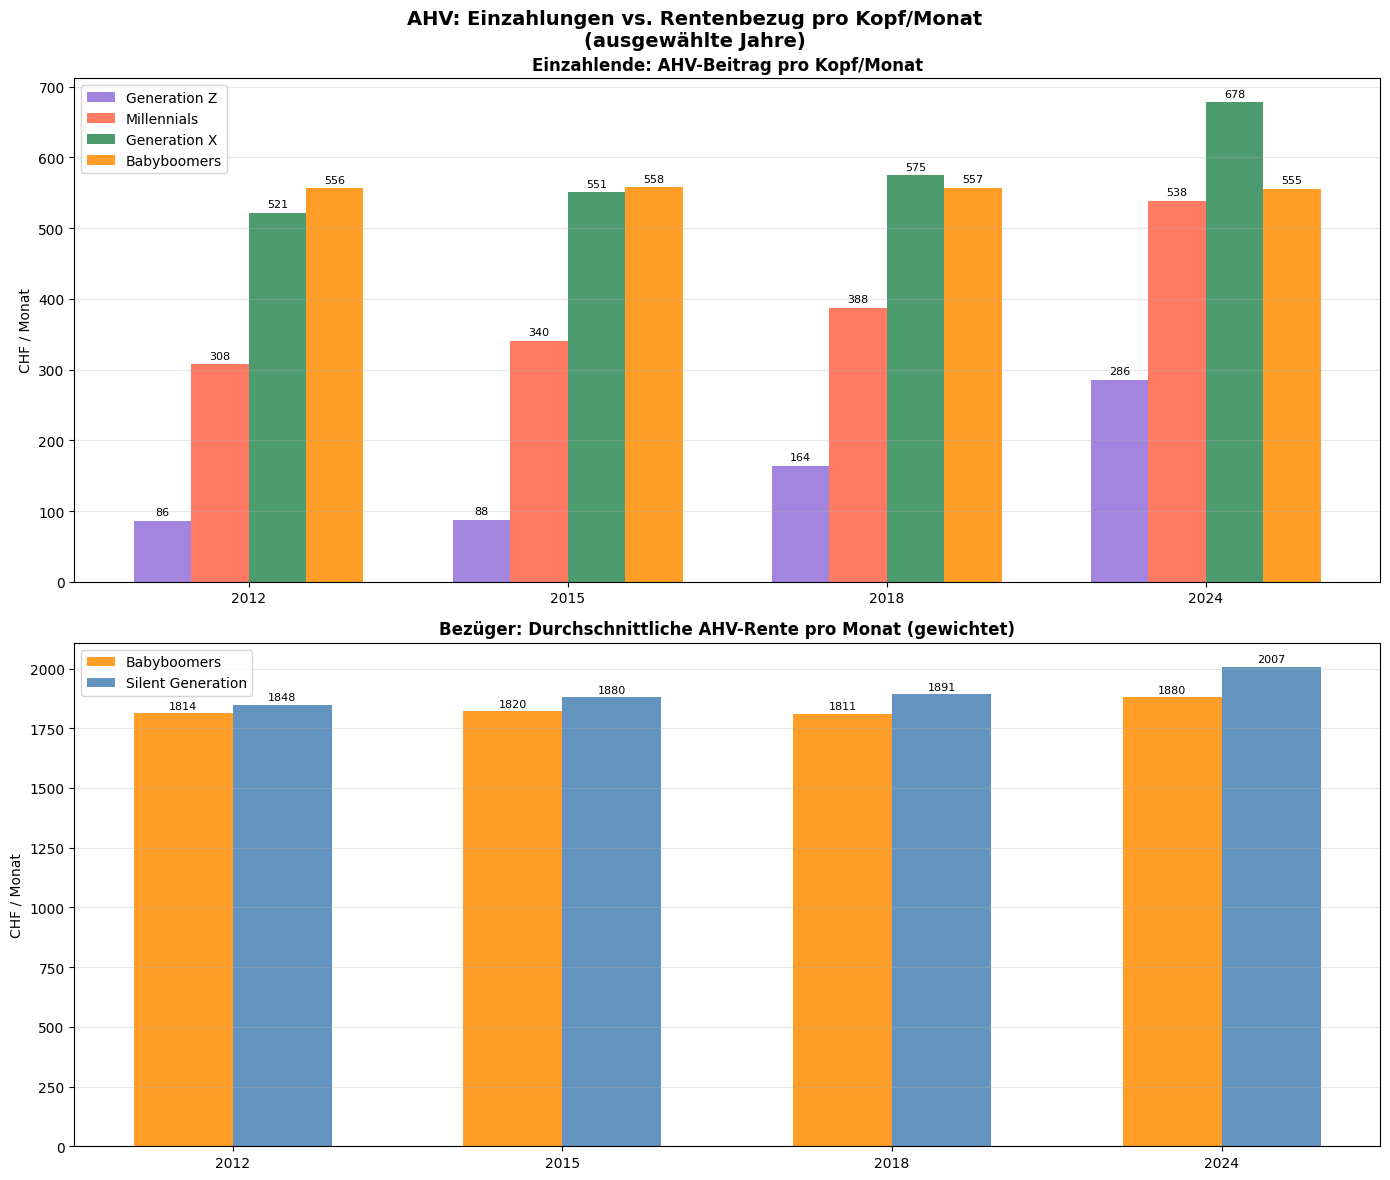

In [38]:
jahre = [2012, 2015, 2018, 2024]
generationen_ein = ['Generation Z', 'Millennials', 'Generation X', 'Babyboomers']
generationen_aus = ['Babyboomers', 'Silent Generation']

fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle('AHV: Einzahlungen vs. Rentenbezug pro Kopf/Monat\n(ausgewählte Jahre)',
             fontsize=14, fontweight='bold')

# --- Subplot 1: Einzahlende ---
ax1 = axes[0]
x = range(len(jahre))
breite = 0.18
farben_ein = {
    'Generation Z':   'mediumpurple',
    'Millennials':    'tomato',
    'Generation X':   'seagreen',
    'Babyboomers':    'darkorange',
}

for i_gen, gen in enumerate(generationen_ein):
    werte = []
    for jahr in jahre:
        n = ahv_ein[
            (ahv_ein['metric'] == 'n_personen') &
            (ahv_ein['project_age_group'] == gen) &
            (ahv_ein['year'] == jahr)
        ]['value'].sum()

        s = ahv_ein[
            (ahv_ein['metric'] == 'sum_beitrag_ahv') &
            (ahv_ein['project_age_group'] == gen) &
            (ahv_ein['year'] == jahr)
        ]['value'].sum()

        werte.append((s / n / 12) if n > 0 else 0)

    offset = (i_gen - 1.5) * breite
    balken = ax1.bar([i + offset for i in x], werte, breite,
                     label=gen, color=farben_ein[gen], alpha=0.85)

    for bar, val in zip(balken, werte):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=8)

ax1.set_title('Einzahlende: AHV-Beitrag pro Kopf/Monat', fontweight='bold')
ax1.set_xticks(list(x))
ax1.set_xticklabels([str(j) for j in jahre])
ax1.set_ylabel('CHF / Monat')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3, axis='y')

# --- Subplot 2: Rentenbezüger (gewichteter Durchschnitt) ---
ax2 = axes[1]
farben_aus = {
    'Babyboomers':       'darkorange',
    'Silent Generation': 'steelblue',
}

breite2 = 0.3
for i_gen, gen in enumerate(generationen_aus):
    werte = []
    for jahr in jahre:
        # Gewichteter Durchschnitt: Mittelwert × Anzahl Renten
        mw = ahv_aus[
            (ahv_aus['metric'] == 'renten_mittelwert_chf') &
            (ahv_aus['project_age_group'] == gen) &
            (ahv_aus['year'] == jahr)
        ][['age', 'value']].rename(columns={'value': 'mittelwert'})

        n = ahv_aus[
            (ahv_aus['metric'] == 'anzahl_renten') &
            (ahv_aus['project_age_group'] == gen) &
            (ahv_aus['year'] == jahr)
        ][['age', 'value']].rename(columns={'value': 'n'})

        merged = mw.merge(n, on='age')
        val = (merged['mittelwert'] * merged['n']).sum() / merged['n'].sum() if len(merged) > 0 else 0
        werte.append(val)

    offset = (i_gen - 0.5) * breite2
    balken = ax2.bar([i + offset for i in x], werte, breite2,
                     label=gen, color=farben_aus[gen], alpha=0.85)

    for bar, val in zip(balken, werte):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=8)

ax2.set_title('Bezüger: Durchschnittliche AHV-Rente pro Monat (gewichtet)', fontweight='bold')
ax2.set_xticks(list(x))
ax2.set_xticklabels([str(j) for j in jahre])
ax2.set_ylabel('CHF / Monat')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

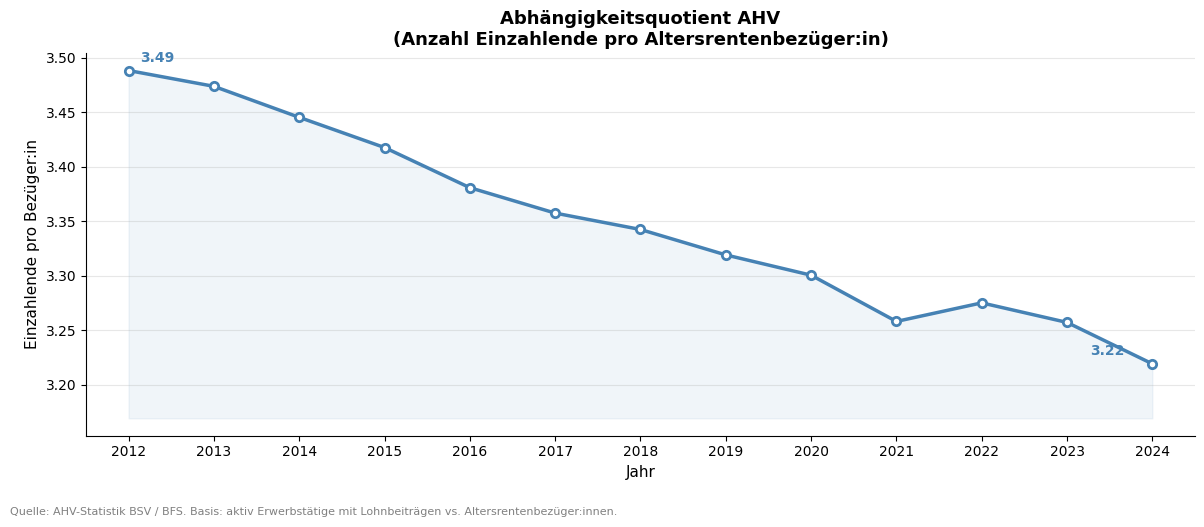

In [39]:
# VIZ 2: Abhängigkeitsquotient AHV (Liniendiagramm)
# Basis: verhaeltnis-DataFrame aus Cell 18

jahr_min = int(verhaeltnis['year'].min())
viz2_data = verhaeltnis[verhaeltnis['year'] >= jahr_min].copy()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(viz2_data['year'], viz2_data['ratio'],
        color='steelblue', linewidth=2.5,
        marker='o', markersize=6,
        markerfacecolor='white', markeredgewidth=2)

ax.fill_between(viz2_data['year'], viz2_data['ratio'], viz2_data['ratio'].min() - 0.05,
                color='steelblue', alpha=0.08)

# Erste und letzte Datenpunkte beschriften
for idx in [0, -1]:
    row = viz2_data.iloc[idx]
    ax.annotate(f"{row['ratio']:.2f}",
                xy=(row['year'], row['ratio']),
                xytext=(8 if idx == 0 else -45, 6),
                textcoords='offset points',
                fontsize=10, fontweight='bold', color='steelblue')

ax.set_xlim(2011.5, 2024.5)
ax.set_xticks(viz2_data['year'])
ax.set_xlabel('Jahr', fontsize=11)
ax.set_ylabel('Einzahlende pro Bezüger:in', fontsize=11)
ax.set_title('Abhängigkeitsquotient AHV\n(Anzahl Einzahlende pro Altersrentenbezüger:in)',
             fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

fig.text(0, -0.04,
         'Quelle: AHV-Statistik BSV / BFS. Basis: aktiv Erwerbstätige mit Lohnbeiträgen vs. Altersrentenbezüger:innen.',
         fontsize=8, color='gray')

plt.tight_layout()
plt.show()

In [40]:
# Kontrollrechnung: Prämienverbilligung per capita nach Fix
# Erwartung: Werte sollten jetzt plausibel sein (nicht mehr um Faktor ~5 zu klein)

# Neu laden (CSV wurde durch Pipeline-Fix aktualisiert)
okp = pd.read_csv('../data/whopays/processed_whopays/okp_by_birth_year.csv')

# Babyboomers 2024 als Kontrollgruppe (wie in Cell 12)
pv_total = okp[
    (okp['variable_name'] == 'praemienverbilligung') &
    (okp['metric'] == 'total_mio_chf') &
    (okp['project_age_group'] == 'Babyboomers') &
    (okp['year'] == 2024)
].set_index('age')['value']

pv_count = okp[
    (okp['variable_name'] == 'praemienverbilligung') &
    (okp['metric'] == 'beneficiaries_count') &
    (okp['project_age_group'] == 'Babyboomers') &
    (okp['year'] == 2024)
].set_index('age')['value']

# Per capita = Total CHF / Anzahl Bezüger / 12 Monate
pv_per_capita_month = (pv_total * 1_000_000) / pv_count / 12

print('Per-Capita Prämienverbilligung pro Monat (Babyboomers, 2024):')
print(pv_per_capita_month.head(10).round(2).to_string())
print(f'\nDurchschnitt: CHF {pv_per_capita_month.mean():.2f}/Monat')
print(f'Min: CHF {pv_per_capita_month.min():.2f} | Max: CHF {pv_per_capita_month.max():.2f}')

# Plausibilitätscheck: Gemäss BAG liegt die durchschnittliche Prämienverbilligung
# in der Schweiz bei ca. CHF 150-200/Monat pro Bezüger
# Quelle: BAG Statistik der obligatorischen Krankenversicherung
print('\n→ Plausibel wenn Durchschnitt im Bereich CHF 150–200/Monat liegt')

Per-Capita Prämienverbilligung pro Monat (Babyboomers, 2024):
age
60    266.43
61    292.44
62    292.44
63    292.44
64    292.44
65    292.44
66    326.23
67    326.23
68    326.23
69    326.23

Durchschnitt: CHF 313.04/Monat
Min: CHF 266.43 | Max: CHF 326.23

→ Plausibel wenn Durchschnitt im Bereich CHF 150–200/Monat liegt


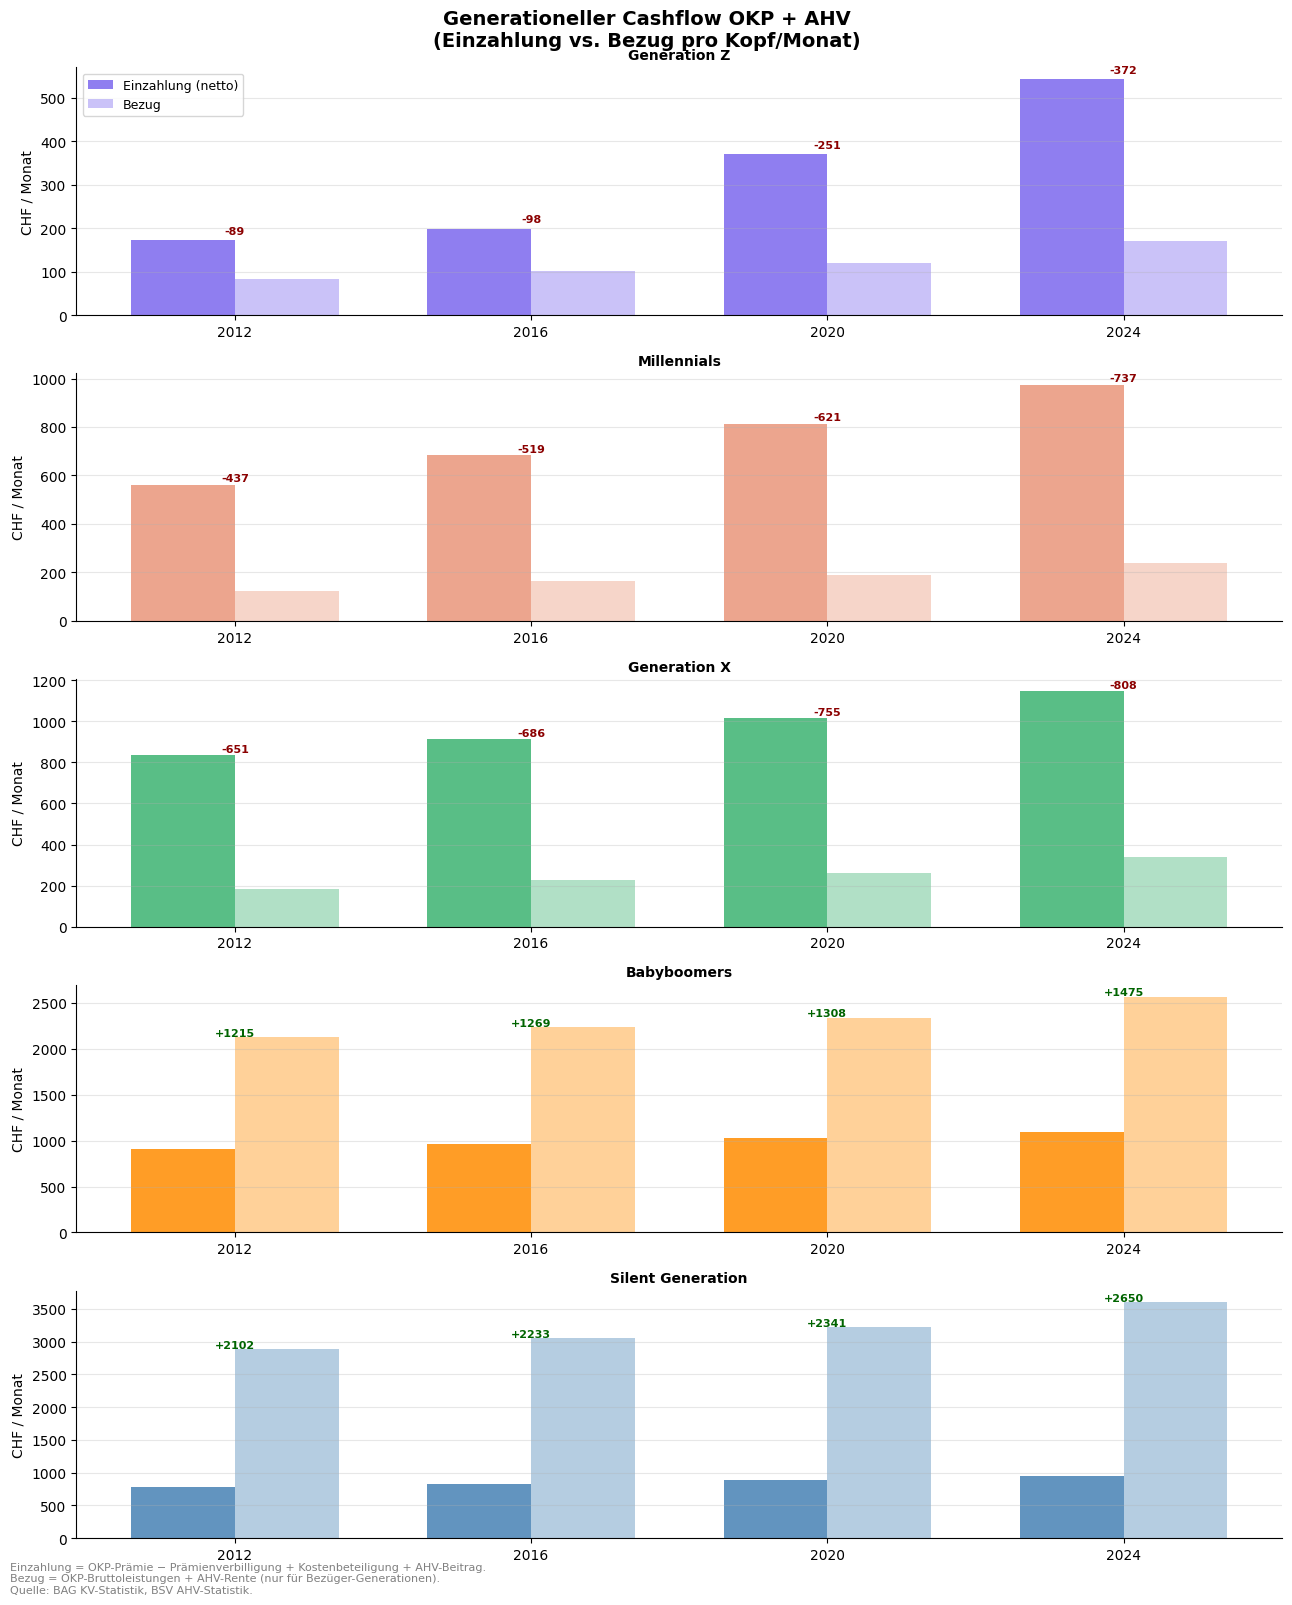

In [41]:
# VIZ 3: Kombinierter Cashflow OKP + AHV nach Generation (ausgewählte Jahre)
# Methode:
# Einzahlung (negativ): OKP-Prämie - Prämienverbilligung (pro Versicherten) + OKP-Kostenbeteiligung + AHV-Beitrag
# Bezug (positiv):      OKP-Bruttoleistungen (pro Versicherten) + AHV-Rente (nur für Bezüger-Generationen)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

jahre_gemeinsam = sorted(
    set(okp['year'].unique()) & set(ahv_ein['year'].unique()) & set(ahv_aus['year'].unique())
)
idx = [0, len(jahre_gemeinsam)//3, 2*len(jahre_gemeinsam)//3, -1]
JAHRE = [jahre_gemeinsam[i] for i in idx]
GENS  = ['Generation Z', 'Millennials', 'Generation X', 'Babyboomers', 'Silent Generation']
BEZÜGER_GENS = ['Babyboomers', 'Silent Generation']

farben = {
    'Generation Z':    '#7B68EE',
    'Millennials':     '#E9967A',
    'Generation X':    '#3CB371',
    'Babyboomers':     '#FF8C00',
    'Silent Generation': '#4682B4',
}

def get_okp_val(variable, metric, gen, jahr):
    """Per-capita Jahreswert in Monatswert (chf_per_capita_year → /12)."""
    val = okp[
        (okp['variable_name'] == variable) &
        (okp['metric'] == metric) &
        (okp['project_age_group'] == gen) &
        (okp['year'] == jahr)
    ]['value'].mean()
    return (val / 12) if not pd.isna(val) else 0

def get_pv_per_versicherter(gen, jahr):
    """
    Prämienverbilligung pro Versicherten/Monat.
    = (total_mio_chf * 1_000_000) / n_versicherte / 12
    n_versicherte = beneficiaries_count / (beneficiary_rate / 100)
    """
    pv_total = okp[
        (okp['variable_name'] == 'praemienverbilligung') &
        (okp['metric'] == 'total_mio_chf') &
        (okp['project_age_group'] == gen) &
        (okp['year'] == jahr)
    ]['value'].sum()

    pv_count = okp[
        (okp['variable_name'] == 'praemienverbilligung') &
        (okp['metric'] == 'beneficiaries_count') &
        (okp['project_age_group'] == gen) &
        (okp['year'] == jahr)
    ]['value'].sum()

    pv_rate = okp[
        (okp['variable_name'] == 'praemienverbilligung') &
        (okp['metric'] == 'beneficiary_rate') &
        (okp['project_age_group'] == gen) &
        (okp['year'] == jahr)
    ]['value'].mean()

    if pd.isna(pv_rate) or pv_rate == 0 or pd.isna(pv_count) or pv_count == 0:
        return 0

    n_versicherte = pv_count / (pv_rate / 100)
    return (pv_total * 1_000_000) / n_versicherte / 12

def get_ahv_beitrag(gen, jahr):
    n = ahv_ein[
        (ahv_ein['metric'] == 'n_personen') &
        (ahv_ein['project_age_group'] == gen) &
        (ahv_ein['year'] == jahr)
    ]['value'].sum()
    s = ahv_ein[
        (ahv_ein['metric'] == 'sum_beitrag_ahv') &
        (ahv_ein['project_age_group'] == gen) &
        (ahv_ein['year'] == jahr)
    ]['value'].sum()
    return (s / n / 12) if n > 0 else 0

def get_ahv_rente(gen, jahr):
    """Gewichtete Durchschnittsrente pro Bezüger/Monat (nur für Bezüger-Generationen)."""
    if gen not in BEZÜGER_GENS:
        return 0
    aus_n  = ahv_aus[(ahv_aus['metric'] == 'anzahl_renten') &
                     (ahv_aus['project_age_group'] == gen) &
                     (ahv_aus['year'] == jahr)][['age','value']].rename(columns={'value':'n'})
    aus_mw = ahv_aus[(ahv_aus['metric'] == 'renten_mittelwert_chf') &
                     (ahv_aus['project_age_group'] == gen) &
                     (ahv_aus['year'] == jahr)][['age','value']].rename(columns={'value':'mw'})
    merged = aus_n.merge(aus_mw, on='age')
    if merged.empty or merged['n'].sum() == 0:
        return 0
    return (merged['mw'] * merged['n']).sum() / merged['n'].sum()

# --- Daten berechnen ---
data = {}
for gen in GENS:
    data[gen] = {'einzahlung': [], 'bezug': [], 'netto': []}
    for jahr in JAHRE:
        praemie   = get_okp_val('okp_premium',        'per_capita_chf', gen, jahr)
        pv        = get_pv_per_versicherter(gen, jahr)
        kosten    = get_okp_val('okp_kostenbeteiligung', 'per_capita_chf', gen, jahr)
        leistung  = get_okp_val('okp_bruttoleistungen',  'per_capita_chf', gen, jahr)
        ahv_b     = get_ahv_beitrag(gen, jahr)
        ahv_r     = get_ahv_rente(gen, jahr)

        einzahlung = praemie - pv + kosten + ahv_b   # was die Generation ins System gibt
        bezug      = leistung + ahv_r                 # was sie aus dem System erhält
        netto      = bezug - einzahlung               # positiv = Nettoempfänger

        data[gen]['einzahlung'].append(einzahlung)
        data[gen]['bezug'].append(bezug)
        data[gen]['netto'].append(netto)

# --- Plot ---
fig, axes = plt.subplots(len(GENS), 1, figsize=(13, 16), sharex=False)
fig.suptitle('Generationeller Cashflow OKP + AHV\n(Einzahlung vs. Bezug pro Kopf/Monat)',
             fontsize=14, fontweight='bold')

x      = np.arange(len(JAHRE))
breite = 0.35

for idx, gen in enumerate(GENS):
    ax = axes[idx]
    farbe = farben[gen]

    b_ein = ax.bar(x - breite/2, data[gen]['einzahlung'], breite,
                   label='Einzahlung (netto)', color=farbe, alpha=0.85)
    b_bez = ax.bar(x + breite/2, data[gen]['bezug'],      breite,
                   label='Bezug', color=farbe, alpha=0.4)

    # Netto-Differenz annotieren
    for i, (e, b) in enumerate(zip(data[gen]['einzahlung'], data[gen]['bezug'])):
        netto = b - e
        farbe_n = 'darkgreen' if netto > 0 else 'darkred'
        symbol  = '+' if netto > 0 else ''
        ax.text(x[i], max(e, b) + 15, f'{symbol}{netto:.0f}',
                ha='center', fontsize=8, color=farbe_n, fontweight='bold')

    ax.set_title(gen, fontweight='bold', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([str(j) for j in JAHRE])
    ax.set_ylabel('CHF / Monat')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    if idx == 0:
        ax.legend(loc='upper left', fontsize=9)

fig.text(0.01, -0.01,
         'Einzahlung = OKP-Prämie − Prämienverbilligung + Kostenbeteiligung + AHV-Beitrag.\n'
         'Bezug = OKP-Bruttoleistungen + AHV-Rente (nur für Bezüger-Generationen).\n'
         'Quelle: BAG KV-Statistik, BSV AHV-Statistik.',
         fontsize=8, color='gray')

plt.tight_layout()
# plt.savefig('viz3_cashflow_okp_ahv.png', dpi=150, bbox_inches='tight')
plt.show()

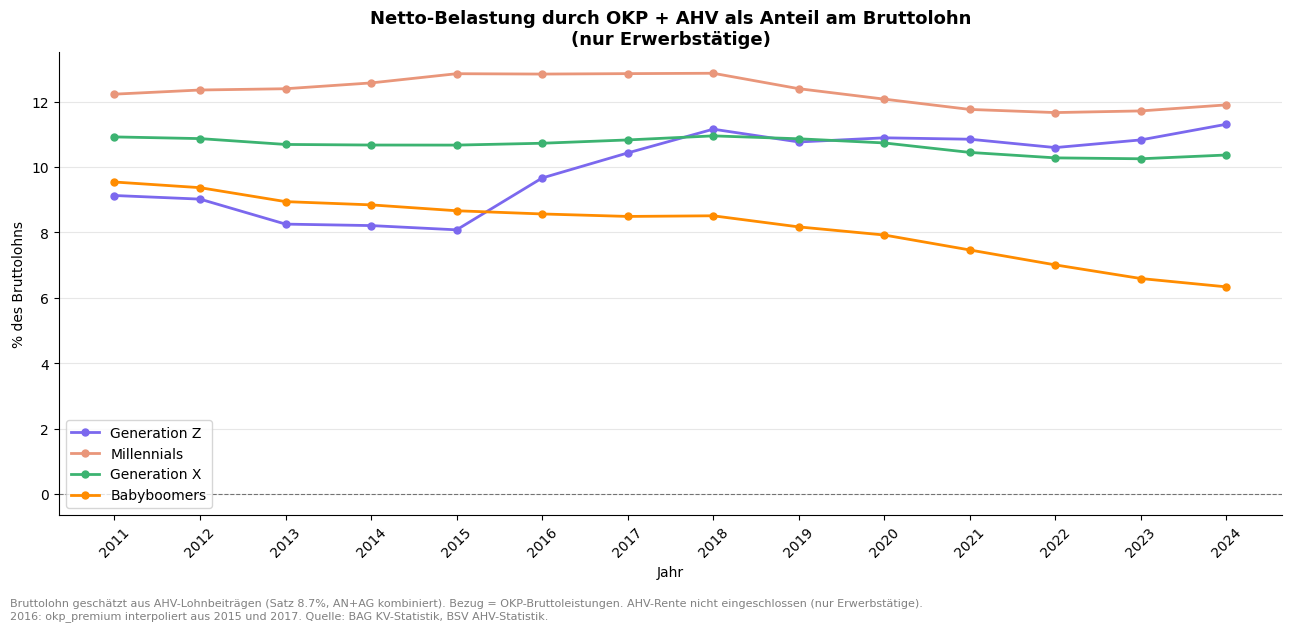

In [42]:
# VIZ 4: Prozentuale monatliche Belastung des Cashflows (nur Erwerbstätige)
# Methode:
# Bruttolohn/Monat = sum_beitrag_ahv / n_personen / 0.087 / 12
# Belastung % = (Einzahlung - Bezug) / Bruttolohn * 100
# Einzahlung = OKP-Prämie - Prämienverbilligung + Kostenbeteiligung + AHV-Beitrag
# Bezug = OKP-Bruttoleistungen (AHV-Rente wird hier ausgeschlossen)

JAHRE_VIZ4 = sorted(
    set(okp[(okp['variable_name'] == 'okp_premium') & (okp['metric'] == 'per_capita_chf')]['year'].unique()) &
    set(ahv_ein['year'].unique())
)
AHV_SATZ   = 0.087  # Arbeitnehmer + Arbeitgeber kombiniert
GENS_VIZ4  = ['Generation Z', 'Millennials', 'Generation X', 'Babyboomers']

farben_viz4 = {
    'Generation Z':  '#7B68EE',
    'Millennials':   '#E9967A',
    'Generation X':  '#3CB371',
    'Babyboomers':   '#FF8C00',
}

def get_bruttolohn(gen, jahr):
    n = ahv_ein[
        (ahv_ein['metric'] == 'n_personen') &
        (ahv_ein['project_age_group'] == gen) &
        (ahv_ein['year'] == jahr)
    ]['value'].sum()
    s = ahv_ein[
        (ahv_ein['metric'] == 'sum_beitrag_ahv') &
        (ahv_ein['project_age_group'] == gen) &
        (ahv_ein['year'] == jahr)
    ]['value'].sum()
    if n == 0:
        return 0
    return (s / n) / AHV_SATZ / 12

resultate = {gen: [] for gen in GENS_VIZ4}

for gen in GENS_VIZ4:
    for jahr in JAHRE_VIZ4:
        praemie  = get_okp_val('okp_premium',          'per_capita_chf', gen, jahr)
        pv       = get_pv_per_versicherter(gen, jahr)
        kosten   = get_okp_val('okp_kostenbeteiligung', 'per_capita_chf', gen, jahr)
        leistung = get_okp_val('okp_bruttoleistungen',  'per_capita_chf', gen, jahr)
        ahv_b    = get_ahv_beitrag(gen, jahr)
        lohn     = get_bruttolohn(gen, jahr)

        einzahlung = praemie - pv + kosten + ahv_b
        bezug      = leistung
        netto      = einzahlung - bezug

        belastung_pct = (netto / lohn * 100) if lohn > 0 else None
        resultate[gen].append(belastung_pct)

# --- Plot ---
fig, ax = plt.subplots(figsize=(13, 6))

for gen in GENS_VIZ4:
    werte = resultate[gen]
    jahre_valid = [j for j, v in zip(JAHRE_VIZ4, werte) if v is not None]
    werte_valid = [v for v in werte if v is not None]
    ax.plot(jahre_valid, werte_valid,
            marker='o', markersize=5, linewidth=2,
            label=gen, color=farben_viz4[gen])

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Netto-Belastung durch OKP + AHV als Anteil am Bruttolohn\n(nur Erwerbstätige)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Jahr')
ax.set_ylabel('% des Bruttolohns')
ax.set_xticks(JAHRE_VIZ4)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='lower left')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

fig.text(0.01, -0.04,
         'Bruttolohn geschätzt aus AHV-Lohnbeiträgen (Satz 8.7%, AN+AG kombiniert). '
         'Bezug = OKP-Bruttoleistungen. AHV-Rente nicht eingeschlossen (nur Erwerbstätige).\n'
         '2016: okp_premium interpoliert aus 2015 und 2017. '
         'Quelle: BAG KV-Statistik, BSV AHV-Statistik.',
         fontsize=8, color='gray')

plt.tight_layout()
plt.show()